In [ ]:
# utilizado para la manipulación de directorios y rutas
import os

# Cálculo científico y vectorial para python
import numpy as np

# Libreria para graficos
from matplotlib import pyplot

# Modulo de optimizacion en scipy
from scipy import optimize

# Para leer el CSV
import pandas as pd

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv("/content/drive/MyDrive/ia/train.csv/Santander.csv")

X = data.drop(columns=["ID", "TARGET"]).values
y = data["TARGET"].values.astype(float)

m = y.size

print(X.shape)   # (76020, 367)
print(y.shape)   # (76020,)


Mounted at /content/drive
(76020, 369)
(76020,)


In [ ]:
X.shape[1]

input_layer_size = X.shape[1]  # 367 automático
num_labels = 2                  # satisfecho o insatisfecho
m = y.size

In [ ]:
def calcularSigmoide(z):
    # Calcula la sigmoide de z.
    return 1.0 / (1.0 + np.exp(-z))

In [ ]:
def calcularCosto(theta, X, y, lambda_):
    # Inicializa algunos valores utiles
    m = y.size

    # convierte las etiquetas a valores enteros si son boleanos
    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)

    h = calcularSigmoide(X.dot(theta.T))
    h = np.clip(h, 1e-10, 1 - 1e-10)

    temp = theta
    temp[0] = 0

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * (h - y).dot(X)
    # Se aplica regularizacion en la siguiente linea
    grad = grad + (lambda_ / m) * temp

    return J, grad

In [ ]:
# valores de prueba para los parámetros theta
theta_t = np.array([-2, -1, 1, 2], dtype=float)

# valores de prueba para las entradas
X_t = np.concatenate((np.ones((5, 1)), np.arange(1, 16).reshape(5, 3, order='F')/10.0), axis=1)
print(X_t)
# valores de testeo para las etiquetas
y_t = np.array([1, 0, 1, 0, 1])

# valores de testeo para el parametro de regularizacion
lambda_t = 3

[[1.  0.1 0.6 1.1]
 [1.  0.2 0.7 1.2]
 [1.  0.3 0.8 1.3]
 [1.  0.4 0.9 1.4]
 [1.  0.5 1.  1.5]]


In [ ]:
J, grad = calcularCosto(theta_t, X_t, y_t, lambda_t)

print('Costo         : {:.6f}'.format(J))
print('-----------------------')
print('Gradientes:')
print(' [{:.6f}, {:.6f}, {:.6f}, {:.6f}]'.format(*grad))

Costo         : 2.534819
-----------------------
Gradientes:
 [0.146561, -0.548558, 0.724722, 1.398003]


In [ ]:
# Balancear clases
idx_clase0 = np.where(y == 0)[0]
idx_clase1 = np.where(y == 1)[0]

# Cuántos hay de cada clase
print(f"Clase 0: {len(idx_clase0)}")
print(f"Clase 1: {len(idx_clase1)}")

# Tomar la misma cantidad de la clase 0 que de la clase 1
np.random.seed(42)
idx_clase0_bal = np.random.choice(idx_clase0, len(idx_clase1), replace=False)

# Juntar y mezclar
idx_bal = np.concatenate([idx_clase0_bal, idx_clase1])
np.random.shuffle(idx_bal)

X = X[idx_bal]
y = y[idx_bal]

print(f"Total balanceado: {len(y)}")
print(f"Clase 0: {np.sum(y==0)}")
print(f"Clase 1: {np.sum(y==1)}")

Clase 0: 73012
Clase 1: 3008
Total balanceado: 6016
Clase 0: 3008
Clase 1: 3008


In [ ]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1  # evitar división por cero
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)
X = X_norm

In [ ]:
def oneVsAll(X, y, num_labels, lambda_):

    m, n = X.shape

    all_theta = np.zeros((num_labels, n + 1))

    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    costos=[]

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        options = {'maxiter': 50}
        res = optimize.minimize(calcularCosto,
                                initial_theta,
                                (X, (y == c), lambda_),
                                jac=True,
                                method='CG',
                                options=options)

        all_theta[c] = res.x

        costos.append(res.fun)

    return all_theta, costos

In [ ]:
lambda_ = 0.1
all_theta, costos = oneVsAll(X, y, num_labels, lambda_)

In [ ]:
print(all_theta)

[[ 3.22834465e-04  7.43649871e-03 -7.24722818e-01 -3.17713834e-02
  -1.31552472e-02  1.09583274e-01  3.10958319e-02  2.55445836e-02
  -7.33970426e-02 -6.38026799e-02 -1.80616231e-01 -2.08741681e-02
   1.10330926e-01 -8.66285617e-02  2.28434535e-02 -1.77839534e-01
  -8.97601828e-02  1.74326577e-02 -1.91023592e-01 -3.15201192e-02
  -2.06486721e-04  1.79092958e-02  0.00000000e+00  0.00000000e+00
   1.35006013e-02 -8.04417939e-02 -3.22269043e-04 -3.22269043e-04
  -1.42358758e-01 -4.75673447e-03  6.94900999e-02  6.62284952e-02
   3.68535337e-02 -7.42308854e-02  6.58849995e-02  4.14533265e-02
   4.14533265e-02 -3.22269043e-04 -3.22269043e-04  1.68455351e-01
   4.77285789e-02 -3.20503220e-02  5.75047811e-02 -7.81280304e-02
  -3.22269043e-04 -3.22269043e-04 -3.12267328e-04  8.89340598e-02
   3.88248913e-02 -9.71944261e-03  8.10272456e-02  2.56122342e-02
  -3.27486809e-03 -4.19107947e-02 -3.27486809e-03  3.76173408e-02
   3.76173408e-02  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000

In [ ]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(calcularSigmoide(X.dot(all_theta.T)), axis=1)

    return p

In [ ]:
print(X.shape)
pred = predictOneVsAll(all_theta, X)
print('Precision del conjuto de entrenamiento: {:.2f}%'.format(np.mean(pred == y) * 100))
XPrueba = X[128:141, :].copy()
yPrueba = y[128:141].copy()
print(XPrueba.shape)
print(len(XPrueba))

XPrueba = np.concatenate((np.ones((13, 1)), XPrueba), axis=1)
print(XPrueba)
p = np.argmax(calcularSigmoide(XPrueba.dot(all_theta.T)), axis=1)
print(p)  # ← sin el + 1

(6016, 369)
Precision del conjuto de entrenamiento: 73.20%
(13, 369)
13
[[ 1.          0.02882424  1.92827047 ... -0.02570862 -0.02579429
  -0.38722684]
 [ 1.          0.02882424 -1.02936657 ... -0.02570862 -0.02579429
   0.08135414]
 [ 1.          0.02903244 -1.02936657 ... -0.02570862 -0.02579429
  -0.53163871]
 ...
 [ 1.          0.02882424 -0.56237125 ... -0.02570862 -0.02579429
   0.13767127]
 [ 1.          0.02882424 -0.95153402 ... -0.02570862 -0.02579429
  -0.36581858]
 [ 1.          0.02882424  1.61694025 ... -0.02570862 -0.02579429
  -0.11946806]]
[1 1 0 1 0 1 0 1 1 1 0 0 1]


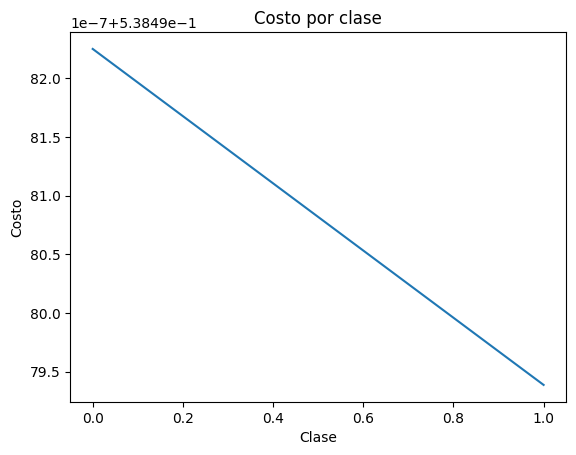

In [ ]:
pyplot.plot(costos)
pyplot.xlabel('Clase')
pyplot.ylabel('Costo')
pyplot.title('Costo por clase')
pyplot.show()

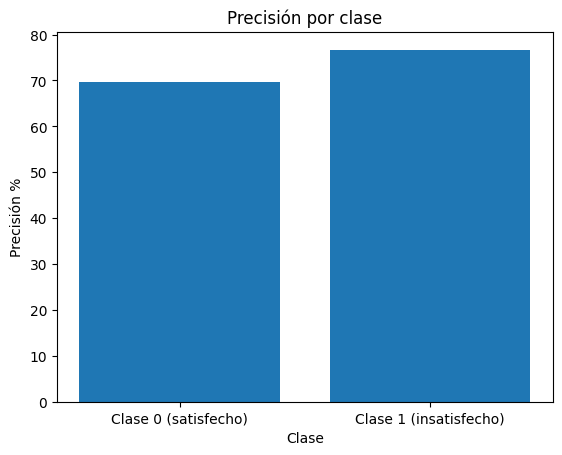

In [ ]:
pred = predictOneVsAll(all_theta, X)

precisiones = []
for c in np.arange(num_labels):
    mask = (y == c)
    precision_clase = np.mean(pred[mask] == y[mask]) * 100
    precisiones.append(precision_clase)

pyplot.bar([0, 1], precisiones)                                          # ← cambio
pyplot.xticks([0, 1], ['Clase 0 (satisfecho)', 'Clase 1 (insatisfecho)'])
pyplot.xlabel('Clase')
pyplot.ylabel('Precisión %')
pyplot.title('Precisión por clase')
pyplot.show()